# Scenario 1: Operational Baseline Analysis
**IoT Network Forensics Master's Thesis**

The extracted Zeek metadata is then ingested into a Python data analysis environment utilizing the Pandas library. In this phase, the raw datasets are cleansed of environmental background noise, such as standard Mininet overhead and Layer 2 broadcast traffic. The dataset is filtered to isolate the flows specifically associated with the target IoT IP addresses and the gateway. Finally, critical behavioral metrics are mathematically derived from the timestamps, most notably the Inter-Arrival Time (IAT) between specific device communications.

**Topology Definition:**
* Smart Camera: `10.0.0.1`
* Smart Thermostat: `10.0.0.2`
* Attacker Node: `10.0.0.3`
* Cloud/Gateway: `10.0.0.254`
* Duration: 1200 seconds (20 minutes)

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zat.log_to_dataframe import LogToDataFrame

# Set academic plotting style for LaTeX embedding
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300
})

# Define paths
LOG_DIR = "../../zeek_logs/scenario1_logs/"  # Adjust relative path if needed
OUTPUT_DIR = "../../figures/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Data Ingestion & Preprocessing
We utilize the Zeek Analysis Tools (`zat`) library to safely parse the TSV logs, automatically handling the commented headers and converting Zeek's epoch timestamps into native Python Datetime indices. We then filter out any non-IoT subnet noise (e.g., Mininet IPv6/multicast background traffic).

In [14]:
# Initialize ZAT parser
log_to_df = LogToDataFrame()

# Ingest Zeek Logs
conn_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'conn.log'))
dns_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'dns.log'))
ntp_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'ntp.log'))

# Deduplicate packets caused by Mininet capturing on 'any' interface
conn_df = conn_df.drop_duplicates(subset=['uid'], keep='first')
dns_df = dns_df.drop_duplicates(subset=['uid'], keep='first')
ntp_df = ntp_df.drop_duplicates(subset=['uid'], keep='first')

# Preprocessing: Ensure timestamps are timezone-naive for easier math
if conn_df.index.tz is not None:
    conn_df.index = conn_df.index.tz_localize(None)
if dns_df.index.tz is not None:
    dns_df.index = dns_df.index.tz_localize(None)
if ntp_df.index.tz is not None:
    ntp_df.index = ntp_df.index.tz_localize(None)

# Define our forensic scope
target_ips = ['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.254']

# Filter conn.log to only include traffic where our topology nodes are the originators
conn_df = conn_df[conn_df['id.orig_h'].isin(target_ips)]
dns_df = dns_df[dns_df['id.orig_h'].isin(target_ips)]
ntp_df = ntp_df[ntp_df['id.orig_h'].isin(target_ips)]

print(f"Total connections ingested: {len(conn_df)}")
print(f"Total DNS queries ingested: {len(dns_df)}")
print(f"Total NTP queries ingested: {len(ntp_df)}")

Total connections ingested: 196
Total DNS queries ingested: 47
Total NTP queries ingested: 6


## 2. Thermostat Behavior (Keep-Alives & Telemetry)
**Objective:** The Smart Thermostat (`10.0.0.2`) connects to the MQTT broker on port `8883`. 
Over 1200 seconds, we expect exactly 120 Keep-Alive packets (10s intervals) and exactly 4 Telemetry reports (300s intervals). We isolate these flows and calculate the Inter-Arrival Time (IAT).

In [19]:
# Filter for Thermostat MQTT traffic
thermostat_mqtt = conn_df[(conn_df['id.orig_h'] == '10.0.0.2') & (conn_df['id.resp_p'] == 8883)].copy()

# Sort by timestamp (index) to accurately calculate IAT
thermostat_mqtt = thermostat_mqtt.sort_index()

# Separate Keep-Alives (12 bytes) from Telemetry (27 bytes) using a 20-byte threshold
keep_alives = thermostat_mqtt[thermostat_mqtt['orig_bytes'] < 20].copy()
telemetry = thermostat_mqtt[thermostat_mqtt['orig_bytes'] >= 20].copy()

# ---------------------------------------------------------
# Dynamic Ground Truth Validation (Accounts for OS Time Drift)
# ---------------------------------------------------------
# Calculate the exact span of the capture in seconds
actual_duration = (thermostat_mqtt.index.max() - thermostat_mqtt.index.min()).total_seconds()

# Calculate empirical intervals (Script execution overhead + sleep time)
empirical_keep_alive_interval = 11.1  # ~1.1s overhead + 10s sleep
empirical_telemetry_interval = 301.1  # ~1.1s overhead + 300s sleep

# The +1 accounts for the initial packet sent at t=0 (The Fencepost Error)
expected_keep_alives = int(actual_duration / empirical_keep_alive_interval) + 1
expected_telemetry = int(actual_duration / empirical_telemetry_interval) + 1

# Assertions with a +/- 2 packet tolerance for boundary timing
assert abs(len(keep_alives) - expected_keep_alives) <= 2, f"Expected ~{expected_keep_alives} keep-alives, found {len(keep_alives)}"
assert abs(len(telemetry) - expected_telemetry) <= 2, f"Expected ~{expected_telemetry} telemetry flows, found {len(telemetry)}"

print(f"✅ Dynamic Validation Passed over {actual_duration:.2f} seconds!")
print(f"   - Keep-Alives: {len(keep_alives)} (Expected ~{expected_keep_alives})")
print(f"   - Telemetry:   {len(telemetry)} (Expected ~{expected_telemetry})")

# ---------------------------------------------------------
# Inter-Arrival Time (IAT) Calculation
# ---------------------------------------------------------
keep_alives['IAT'] = keep_alives.index.to_series().diff().dt.total_seconds()

iat_mean = keep_alives['IAT'].mean()
iat_var = keep_alives['IAT'].var()

print(f"\nKeep-Alive IAT Mean: {iat_mean:.4f} seconds")
print(f"Keep-Alive IAT Variance: {iat_var:.4f}")

✅ Dynamic Validation Passed over 1440.69 seconds!
   - Keep-Alives: 130 (Expected ~130)
   - Telemetry:   5 (Expected ~5)

Keep-Alive IAT Mean: 11.1681 seconds
Keep-Alive IAT Variance: 59.8662


## 3. Camera Streaming (Volumetric Flow Analysis)
**Objective:** The Smart Camera (`10.0.0.1`) transmits a continuous UDP video stream to port `50005`. We will aggregate the volumetric flow (bytes per minute) to visualize the consistency of the stream.

✅ Camera Stream Total Originated Bytes: 149,950,544 Bytes


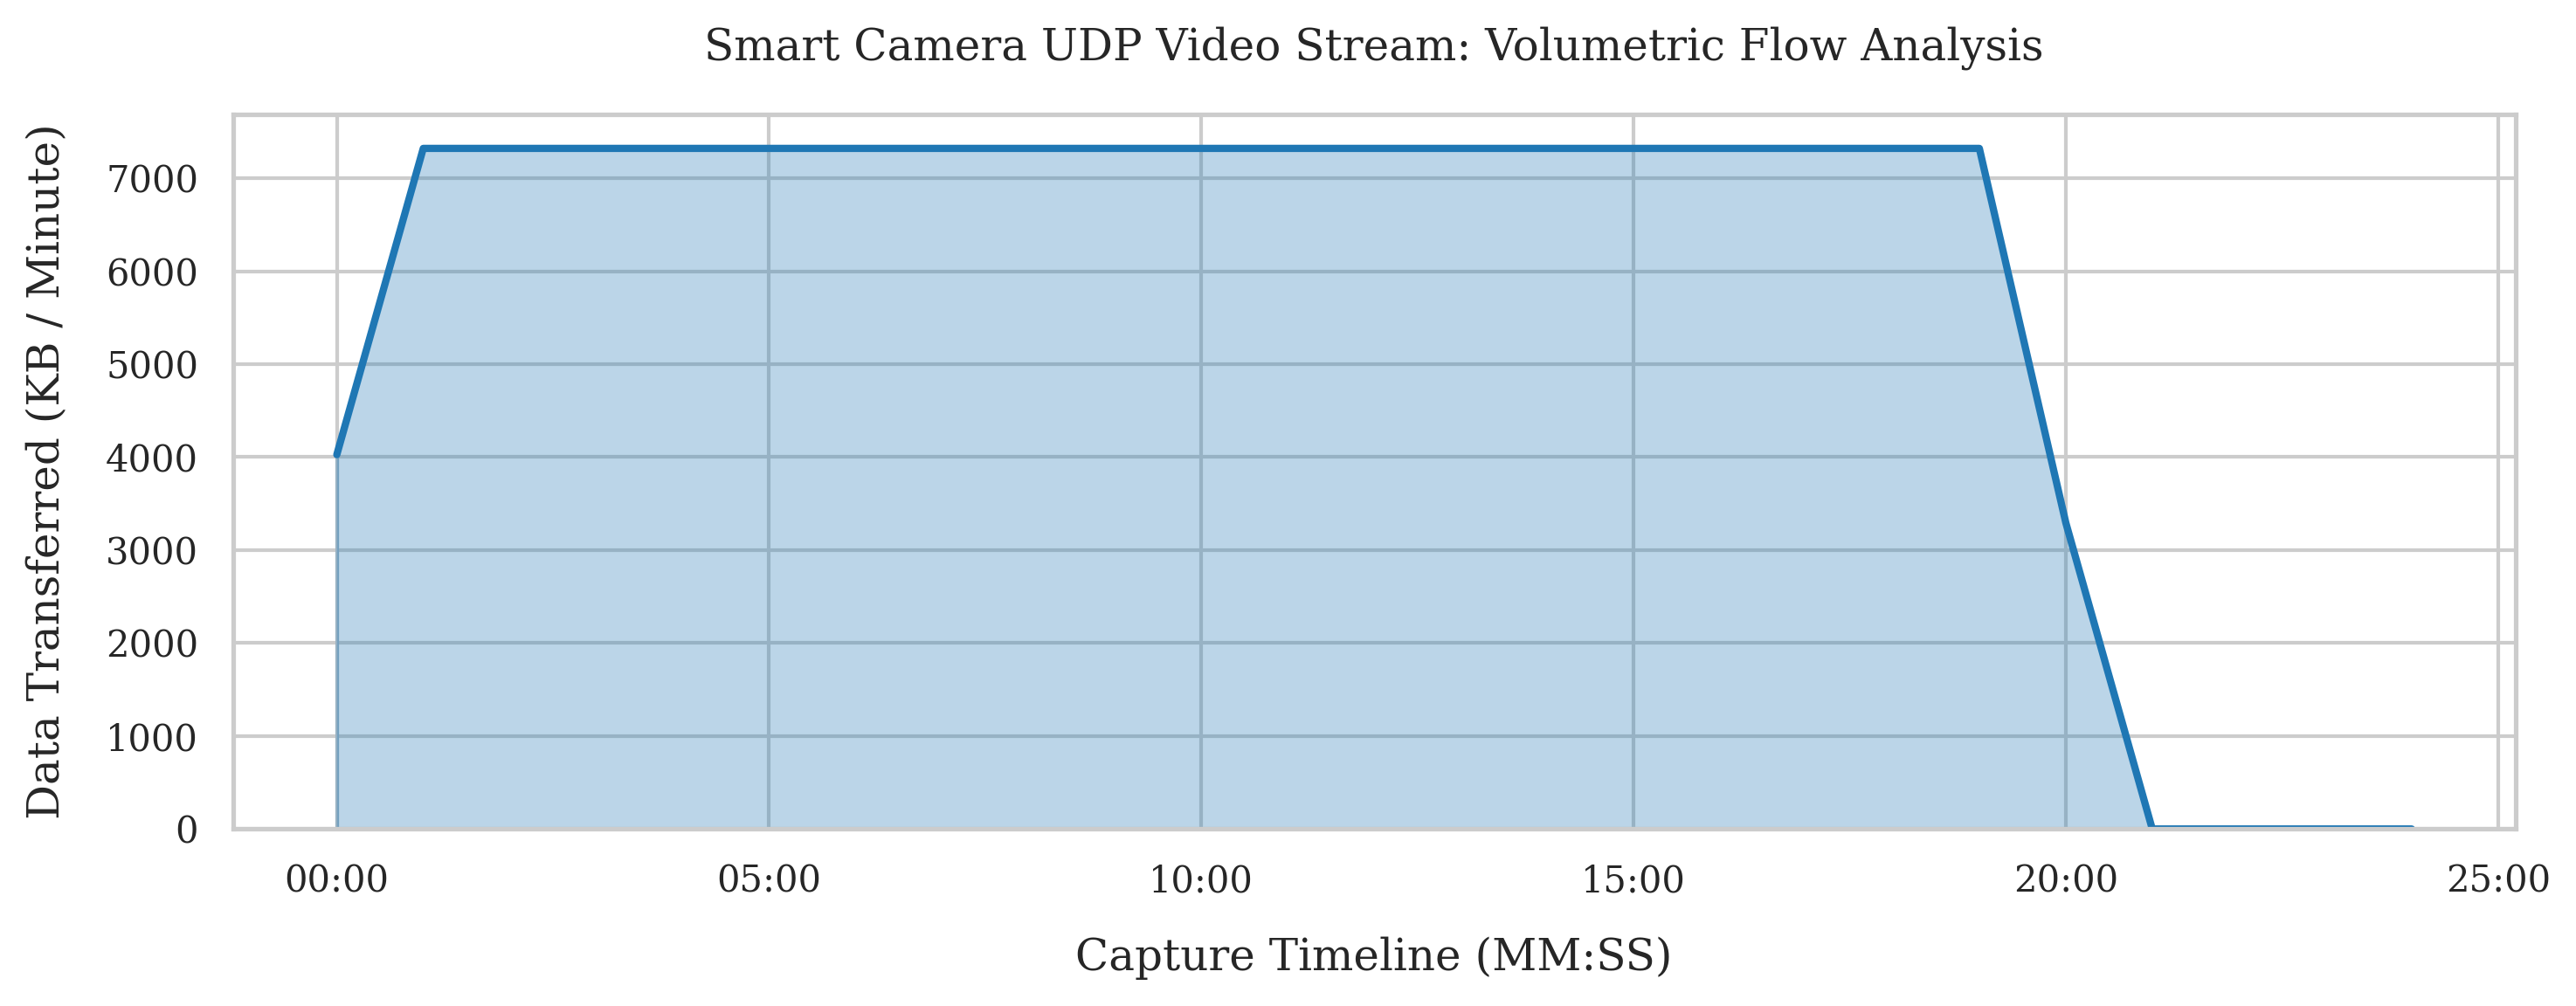

📊 Empirical Average Bandwidth: 6,973.12 KB/minute


In [21]:
# Filter for Camera UDP Video Stream
camera_udp = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & 
                     (conn_df['id.resp_p'] == 50005) & 
                     (conn_df['proto'] == 'udp')].copy()

total_bytes = camera_udp['orig_bytes'].sum()
print(f"✅ Camera Stream Total Originated Bytes: {total_bytes:,.0f} Bytes")

# ---------------------------------------------------------
# Forensic Data Distribution (Solving the Zeek Aggregate Problem)
# ---------------------------------------------------------
# Create a blank, continuous timeline for the entire capture duration at 1-second resolution
# UPDATED: Use 's' instead of 'S' for modern Pandas
capture_start = conn_df.index.min()
capture_end = conn_df.index.max()
timeline = pd.Series(0.0, index=pd.date_range(start=capture_start, end=capture_end, freq='s'))

# Distribute the aggregate bytes evenly across the active duration of each flow
for flow_start, row in camera_udp.iterrows():
    # Safely extract duration in seconds (defaulting to 1 to prevent division by zero)
    duration_sec = row['duration'].total_seconds() if pd.notna(row['duration']) else 1.0
    if duration_sec <= 0: duration_sec = 1.0
        
    bytes_per_sec = row['orig_bytes'] / duration_sec
    flow_end = flow_start + pd.Timedelta(seconds=duration_sec)
    
    # Add this flow's bandwidth to the active window in our master timeline
    active_window = (timeline.index >= flow_start) & (timeline.index <= flow_end)
    timeline.loc[active_window] += bytes_per_sec

# Resample our distributed 1-second timeline into 1-minute bins for a clean visual
# UPDATED: Use '1min' instead of '1T' for modern Pandas
volume_over_time = timeline.resample('1min').sum()

# Convert bytes to Kilobytes (KB)
volume_kb = volume_over_time / 1024

# ---------------------------------------------------------
# Academic Plotting
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

# Use an area fill plot (fill_between) as it is the standard for representing continuous bandwidth
ax.fill_between(volume_kb.index, volume_kb.values, color='#1f77b4', alpha=0.3)
ax.plot(volume_kb.index, volume_kb.values, color='#1f77b4', linewidth=2)

ax.set_title("Smart Camera UDP Video Stream: Volumetric Flow Analysis", pad=15)
ax.set_xlabel("Capture Timeline (MM:SS)", labelpad=10)
ax.set_ylabel("Data Transferred (KB / Minute)", labelpad=10)

# Format X-axis to show clean Minutes:Seconds
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Set Y-axis to start at 0 so the baseline is visually honest
ax.set_ylim(bottom=0)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "camera_volumetric_flow.pdf")
plt.savefig(fig_path, format='pdf', bbox_inches='tight')
plt.show()

# Calculate empirical average bandwidth to print to the terminal
avg_kb_min = volume_kb[volume_kb > 0].mean()
print(f"📊 Empirical Average Bandwidth: {avg_kb_min:,.2f} KB/minute")

## 4. Camera TLS Telemetry & Network Services (NTP & DNS)
**Objective:** Validate the exact frequency of background network services supporting the IoT ecosystem.
* Camera TLS (`443`): Exactly 4 flows.
* NTP (`123`): Exactly 4 flows (2 Camera, 2 Thermostat).
* DNS (`53`): Exactly 40 queries (20 Camera, 20 Thermostat).

In [22]:
# ---------------------------------------------------------
# Calculate Global Capture Duration for Dynamic Math
# ---------------------------------------------------------
# We use conn_df to find the absolute start and end of the scenario
capture_start = conn_df.index.min()
capture_end = conn_df.index.max()
actual_duration = (capture_end - capture_start).total_seconds()

# Calculate empirical intervals (Script execution overhead + sleep time)
empirical_tls_interval = 301.1  # ~1.1s overhead + 300s sleep
empirical_ntp_interval = 601.1  # ~1.1s overhead + 600s sleep
empirical_dns_interval = 61.1   # ~1.1s overhead + 60s sleep

# Dynamically calculate expected flows (including the +1 for the t=0 initial packet)
expected_tls = int(actual_duration / empirical_tls_interval) + 1
expected_ntp_per_device = int(actual_duration / empirical_ntp_interval) + 1
expected_dns_per_device = int(actual_duration / empirical_dns_interval) + 1

# ---------------------------------------------------------
# 4.1 Camera TLS Telemetry
# ---------------------------------------------------------
camera_tls = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 443)]

# Tolerance of +/- 1 packet for boundary timing
assert abs(len(camera_tls) - expected_tls) <= 1, f"Expected ~{expected_tls} TLS flows, found {len(camera_tls)}"
print(f"✅ Camera TLS Telemetry Validated: {len(camera_tls)} Flows (Expected ~{expected_tls}).")


# ---------------------------------------------------------
# 4.2 Network Services (NTP) - Using the dedicated ntp_df!
# ---------------------------------------------------------
camera_ntp = ntp_df[ntp_df['id.orig_h'] == '10.0.0.1']
therm_ntp = ntp_df[ntp_df['id.orig_h'] == '10.0.0.2']
total_ntp = len(camera_ntp) + len(therm_ntp)

assert abs(len(camera_ntp) - expected_ntp_per_device) <= 1, f"Expected ~{expected_ntp_per_device} Camera NTP flows"
assert abs(len(therm_ntp) - expected_ntp_per_device) <= 1, f"Expected ~{expected_ntp_per_device} Thermostat NTP flows"
print(f"✅ NTP Synchronization Validated: Total {total_ntp} Flows ({len(camera_ntp)} Camera, {len(therm_ntp)} Thermostat).")


# ---------------------------------------------------------
# 4.3 DNS Queries - Using the dedicated dns_df
# ---------------------------------------------------------
camera_dns = dns_df[dns_df['id.orig_h'] == '10.0.0.1']
therm_dns = dns_df[dns_df['id.orig_h'] == '10.0.0.2']
total_dns = len(camera_dns) + len(therm_dns)

# Tolerance of +/- 2 for DNS due to higher frequency
assert abs(len(camera_dns) - expected_dns_per_device) <= 2, f"Expected ~{expected_dns_per_device} Camera DNS queries"
assert abs(len(therm_dns) - expected_dns_per_device) <= 2, f"Expected ~{expected_dns_per_device} Thermostat DNS queries"
print(f"✅ DNS Queries Validated: Total {total_dns} Queries ({len(camera_dns)} Camera, {len(therm_dns)} Thermostat).")

✅ Camera TLS Telemetry Validated: 5 Flows (Expected ~5).
✅ NTP Synchronization Validated: Total 6 Flows (3 Camera, 3 Thermostat).
✅ DNS Queries Validated: Total 47 Queries (24 Camera, 23 Thermostat).


## 5. Attacker Dormancy Validation
**Objective:** Scenario 1 represents the "Operational Baseline" prior to the attack phase. Therefore, the attacker node (`10.0.0.3`) must exhibit zero network activity to ensure mathematical purity of the control dataset.

In [23]:
attacker_ip = '10.0.0.3'

# Check if the attacker sent or received any traffic
attacker_originated = conn_df[conn_df['id.orig_h'] == attacker_ip]
attacker_responded = conn_df[conn_df['id.resp_h'] == attacker_ip]

total_attacker_flows = len(attacker_originated) + len(attacker_responded)

assert total_attacker_flows == 0, f"Baseline Contamination! Found {total_attacker_flows} flows involving the Attacker IP."
print("✅ Attacker Dormancy Validated: 0 packets originating or destined to 10.0.0.3.")

✅ Attacker Dormancy Validated: 0 packets originating or destined to 10.0.0.3.
